Policy Iteration


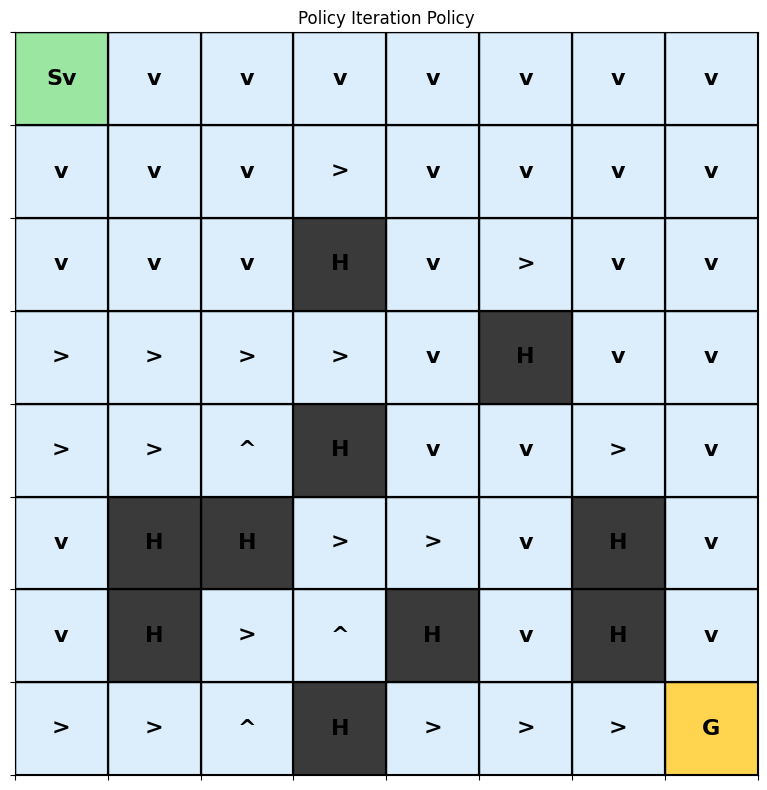

Value Iteration


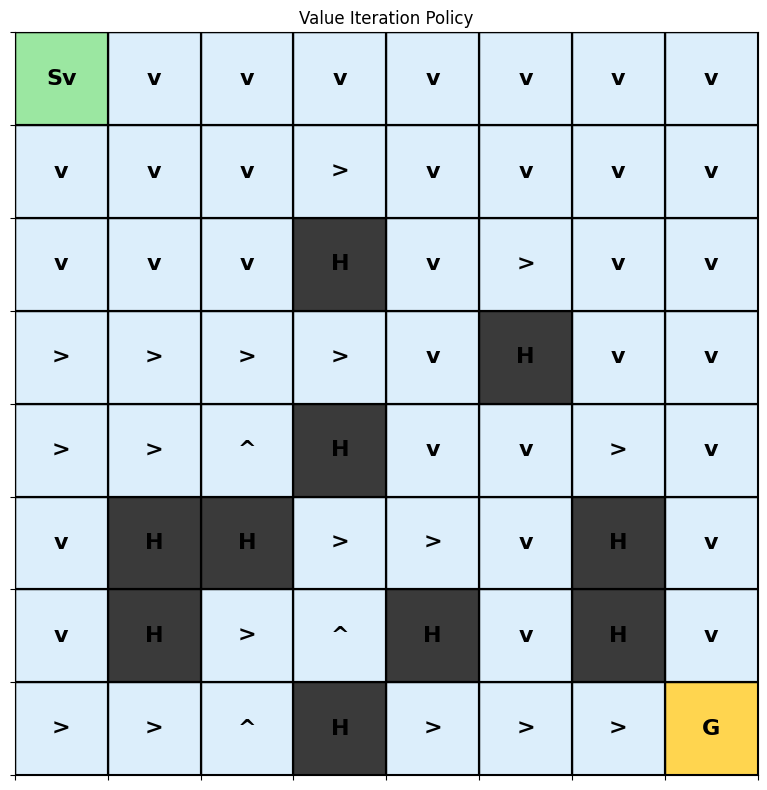

In [1]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt

def build_env(slippery: bool = True):
	return gym.make("FrozenLake-v1", map_name="8x8", is_slippery=slippery)

def extract_model(env: gym.Env):
  n_states=64
  n_actions=4
  # transition=P(s`,r|s,a)
  transition=np.zeros((64,4,64))
  reward=np.zeros((64,4,64))
  for state in range(n_states):
    for action in range(n_actions):
      for prob,next_state,r,_terminated in env.unwrapped.P[state][action]:  #.P is that transition matrix
        transition[state,action,next_state]+=prob
        reward[state,action,next_state]=r

  expected_reward=np.sum(transition*reward,axis=2)
  return transition,reward,expected_reward

def q_values(transition,expected_reward,values,gamma):
  n_states=64
  n_actions=4

  future=np.zeros((n_states,n_actions))
  for s in range(n_states):
    for a in range(n_actions):
      for ns in range(n_states):
        future[s,a]+=transition[s,a,ns]*values[ns]

  return expected_reward+gamma*future

  #using simple relation V(s)= sumtn pi(s|a)q(s,a)
def value_iterations(transition,expected_reward,max_iteration=1000,gamma=0.99):
  n_states=64
  values=np.zeros(n_states)
  for it in range(max_iteration):
    q=q_values(transition,expected_reward,values,gamma)
    new_values=np.max(q,axis=1)
    if np.allclose(values,new_values):
      return values,it+1
    values=new_values
  return values,max_iteration


def policy_eval_matrix(transition,expected_reward,policy,gamma=0.99):
  n_states=64
  n_actions=4
  policy_transition = np.zeros((n_states, n_states))
  policy_reward = np.zeros(n_states)
  for s in range(n_states):
    a=policy[s]
    policy_transition[s]=transition[s,a]
    policy_reward[s] = expected_reward[s, a]

    #V=R+gammaPV=> V=R inv(I-gammaP) then so it is type of Ax=B
  system = np.eye(n_states) -gamma * policy_transition
  values = np.linalg.solve(system,policy_reward)

  return values


def policy_iteration(transition,expected_reward,gamma=0.99,max_iterations=1000):
  n_states=64
  policy=np.zeros(n_states,dtype=int)
  for it in range(max_iterations):
    values=policy_eval_matrix(transition,expected_reward,policy,gamma)
    q=q_values(transition,expected_reward,values,gamma)
    new_policy=np.argmax(q,axis=1)

  #optimal policy condition
    if(np.array_equal(policy,new_policy)):
      return values,policy,it+1
    policy=new_policy
    values=policy_eval_matrix(transition,expected_reward,policy,gamma)

  return values,policy,max_iterations



def plot_policy_on_frozen_lake(env, policy, title="FrozenLake policy"):
	desc = np.asarray(env.unwrapped.desc, dtype=str)
	policy_grid = np.asarray(policy).reshape(desc.shape)
	arrows = np.array(["<", "v", ">", "^"])
	colors = {
		"S": "#9be7a1",
		"F": "#dceefb",		"H": "#3a3a3a",
		"G": "#ffd54f",
	}

	fig, ax = plt.subplots(figsize=(8, 8))
	for r in range(desc.shape[0]):
		for c in range(desc.shape[1]):
			tile = desc[r, c]
			rect = plt.Rectangle((c, desc.shape[0] - 1 - r), 1, 1, facecolor=colors[tile], edgecolor="black", linewidth=1.5)
			ax.add_patch(rect)

			if tile == "H":
				label = "H"
			elif tile == "G":
				label = "G"
			elif tile == "S":
				label = f"S{arrows[policy_grid[r, c]]}"
			else:
				label = arrows[policy_grid[r, c]]

			ax.text(c + 0.5, desc.shape[0] - 1 - r + 0.5, label, ha="center", va="center", fontsize=16, fontweight="bold", color="black")

	ax.set_xlim(0, desc.shape[1])
	ax.set_ylim(0, desc.shape[0])
	ax.set_xticks(np.arange(desc.shape[1] + 1))
	ax.set_yticks(np.arange(desc.shape[0] + 1))
	ax.grid(True, color="black", linewidth=1.0)
	ax.set_xticklabels([])
	ax.set_yticklabels([])
	ax.set_aspect("equal")
	ax.set_title(title)
	plt.tight_layout()
	plt.show()

def main():
	gamma = 0.99
	env = build_env(slippery=False)
	transition, reward, expected_reward = extract_model(env)

	print("Policy Iteration")
	values_pi, policy_pi, iterations_pi = policy_iteration(transition, expected_reward, gamma)
	plot_policy_on_frozen_lake(env, policy_pi, title="Policy Iteration Policy")

	print("Value Iteration")
	values_vi, iterations_vi = value_iterations(transition, expected_reward, gamma=gamma)
	q_vi = q_values(transition, expected_reward, values_vi, gamma)
	policy= np.argmax(q_vi, axis=1)
	plot_policy_on_frozen_lake(env, policy, title="Value Iteration Policy")


main()